# End-to-end gene network tutorial

Build a context-conditional gene correlation network from your own scRNA-seq data.

```
input directory of per-cell-type h5ad files
    │
    ▼  build_metacells_dir         → dict[cell_type, metacell AnnData]
    ▼  build_corr_db               → on-disk corr DB ({name}_corr_{ct}_{version}.npy
    │                                 + gene_names + n_obs)
    ▼  build_multi_goi_features    → feature matrix across (GOI, cell_type) conditions
    ▼  build_gene_network          → per-GOI gene network grid
```

This walkthrough uses lung scRNA-seq split into three cell-type compartments
(Endothelial/Stromal, Epithelial, Immune) and the CDKN gene family as genes of
interest. Replace the placeholder paths with your own.

In [16]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

from sceleto.network import (
    build_metacells_dir,
    build_corr_db,
    load_corr_db,
    list_cell_types,
    select_top_genes,
    build_feature_matrix,
    build_gene_network,
    plot_network,
    plot_clustermap,
    build_multi_goi_features,
)

## 1. Prepare the input directory

`build_metacells_dir` reads every `*.h5ad` in a directory and treats each file
as one cell type (file stem becomes the cell-type name). If your raw data
folder mixes the target h5ad files with other unrelated files, isolate the
ones you want via symlinks or a clean subdirectory.

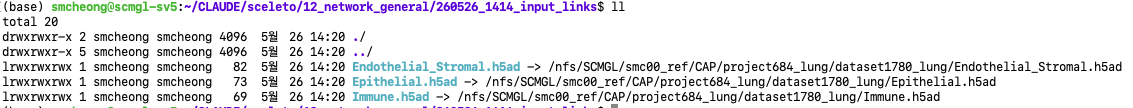

In [17]:
LINKS_DIR = Path('path/to/input_dir')
LINKS_DIR.mkdir(exist_ok=True)

for fname in ['Endothelial_Stromal.h5ad', 'Epithelial.h5ad', 'Immune.h5ad']:
    dst = LINKS_DIR / fname
    if not dst.exists():
        dst.symlink_to(f'path/to/source_h5ad_dir/{fname}')

for f in sorted(LINKS_DIR.glob('*.h5ad')):
    print(f'{f.name:30s}  {f.resolve().stat().st_size/1e9:6.2f} GB')

Endothelial_Stromal.h5ad          2.67 GB
Epithelial.h5ad                  15.54 GB
Immune.h5ad                       9.62 GB


## 2. Build metacells per cell type

`build_metacells_dir` applies `build_metacells` to every h5ad in the input
directory, building per-sample metacells within each cell type. Set
`sample_key` to the `.obs` column identifying samples — kNN graphs are built
within each sample only. When `output_dir` is provided, the resulting metacell
AnnData is cached as `{output_dir}/{cell_type}.h5ad` and read back on re-run
(idempotent).

In [18]:
metacells = build_metacells_dir(
    'path/to/input_dir',
    'path/to/metacells_cache',
    sample_key='sample',
    counts='raw',
    min_cells_per_sample=100,
    prop=0.1,
    seed=42,
    verbose=True,
)

for ct, mc in metacells.items():
    print(f'  {ct:25s} {mc.n_obs:6d} metacells × {mc.n_vars} genes')

cell types:   0%|                                                                                                                                              | 0/3 [00:00<?, ?it/s]

[Endothelial_Stromal] cached → Endothelial_Stromal.h5ad, reading


cell types:  33%|████████████████████████████████████████████▋                                                                                         | 1/3 [00:04<00:08,  4.11s/it]

[Epithelial] cached → Epithelial.h5ad, reading


cell types:  67%|█████████████████████████████████████████████████████████████████████████████████████████▎                                            | 2/3 [00:23<00:13, 13.19s/it]

[Immune] cached → Immune.h5ad, reading


cell types: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:36<00:00, 12.14s/it]

  Endothelial_Stromal         4135 metacells × 27957 genes
  Epithelial                 16497 metacells × 27957 genes
  Immune                     13091 metacells × 27957 genes


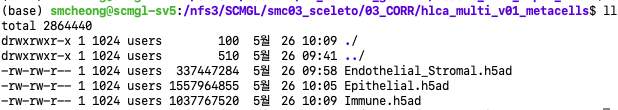

## 2.5 (Optional) unify var_names across cell types

`build_corr_db` requires every cell type's metacell AnnData to share the same
`var_names`. If your input files have differing gene sets (e.g. compartment-
specific QC), intersect them first; you can also rename to gene symbols here
for readability.

In [19]:
common = sorted(set.intersection(*(set(mc.var_names) for mc in metacells.values())))
metacells = {ct: mc[:, common].copy() for ct, mc in metacells.items()}

ref = next(iter(metacells.values())).copy()
ref.var_names = ref.var['feature_name'].astype(str).values
ref.var_names_make_unique()
unified_names = list(ref.var_names)

for mc in metacells.values():
    mc.var_names = unified_names

print(f'shared genes: {len(unified_names)}, all unique? {len(set(unified_names)) == len(unified_names)}')
print('var_names[:5]:', unified_names[:5])

shared genes: 27957, all unique? True
var_names[:5]: ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112']


In [25]:
metacells

{'Endothelial_Stromal': AnnData object with n_obs × n_vars = 4135 × 27957
     obs: 'index_cell', 'n_cells', 'sample'
     var: 'gene_names', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std',
 'Epithelial': AnnData object with n_obs × n_vars = 16497 × 27957
     obs: 'index_cell', 'n_cells', 'sample'
     var: 'gene_names', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std',
 'Immune': AnnData object with n_obs × n_vars = 13091 × 27957
     obs: 'index_cell', 'n_cells', 'sample'
     var: 'gene_names', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'}

## 3. Build the correlation DB

`build_corr_db` computes a per-cell-type (gene × gene) float16 correlation
matrix from the metacell expression and writes it to disk under the
`{name}_..._{version}` convention. With `overwrite=False`, calls are
idempotent; if the on-disk `gene_names` does not match the new input, the
function raises rather than silently leaving a stale DB.

In [20]:
build_corr_db(
    metacells,  # cell type x anndata dictionary
    out_dir='path/to/corr_db',
    name='hlca',
    version='v01',
    overwrite=False,
    verbose=True,
)

[Endothelial_Stromal] hlca_corr_Endothelial_Stromal_v01.npy exists, skipping (overwrite=False)
[Epithelial] hlca_corr_Epithelial_v01.npy exists, skipping (overwrite=False)
[Immune] hlca_corr_Immune_v01.npy exists, skipping (overwrite=False)
[shared] n_obs → hlca_n_obs_v01.json: {'Endothelial_Stromal': 4135, 'Epithelial': 16497, 'Immune': 13091}


PosixPath('/nfs3/SCMGL/smc03_sceleto/03_CORR/hlca_multi_v01')

In [21]:
list_cell_types('path/to/corr_db', name='hlca', version='v01')

['Endothelial_Stromal', 'Epithelial', 'Immune']

## 4. Multi-GOI integrated gene network

For multiple genes of interest, `build_multi_goi_features` returns a single
feature matrix spanning all `(GOI, cell type)` conditions. Feeding it to
`build_gene_network` yields one kNN graph; per-condition visualizations all
share the same node layout for easy comparison.

In [22]:
feat_multi = build_multi_goi_features(
    ['CDKN1A', 'CDKN1B', 'CDKN1C', 'CDKN2A', 'CDKN2B', 'CDKN2C', 'CDKN2D'],
    data_dir='path/to/corr_db',
    top_n=10,
    name='hlca',
    version='v01',
)
G_multi   = build_gene_network(feat_multi, k=5)
pos_multi = nx.spring_layout(G_multi, weight='weight', seed=3)

print(f'feat: {feat_multi.shape}  |  G: {G_multi.number_of_nodes()}n/{G_multi.number_of_edges()}e')

feat: (199, 21)  |  G: 199n/698e


In [26]:
feat_multi

,CDKN1A_Endothelial_Stromal,CDKN1A_Epithelial,CDKN1A_Immune,CDKN1B_Endothelial_Stromal,CDKN1B_Epithelial,CDKN1B_Immune,CDKN1C_Endothelial_Stromal,CDKN1C_Epithelial,CDKN1C_Immune,CDKN2A_Endothelial_Stromal,...,CDKN2A_Immune,CDKN2B_Endothelial_Stromal,CDKN2B_Epithelial,CDKN2B_Immune,CDKN2C_Endothelial_Stromal,CDKN2C_Epithelial,CDKN2C_Immune,CDKN2D_Endothelial_Stromal,CDKN2D_Epithelial,CDKN2D_Immune
gene,,,,,,,,,,,,,,,,,,,,,
ABLIM1,-0.056946,0.093506,-0.276855,-0.114075,0.154785,0.572754,0.279297,0.102539,-0.069153,-0.084045,...,0.191895,0.202881,0.699707,-0.106323,0.193359,0.072510,0.151245,-0.079590,0.164429,0.294434
ADGRE2,0.084961,0.089661,0.587402,0.099060,0.056274,0.090881,-0.050598,0.103760,0.550781,-0.010017,...,-0.179565,-0.035187,0.004063,0.312988,-0.064575,-0.008575,-0.013565,0.065491,0.080688,0.114319
ARHGAP45,-0.014687,0.092407,-0.004601,0.266113,0.258545,0.621582,0.087036,0.075378,0.135376,0.139404,...,0.152832,0.205688,0.245850,0.006561,-0.259766,-0.228027,0.221436,0.221924,-0.052338,0.574219
ARHGAP6,-0.072266,0.006664,0.063599,0.520996,0.058533,-0.377686,0.291992,0.024643,-0.077820,0.073181,...,-0.059021,0.193604,0.285156,0.018143,-0.085083,0.086548,-0.053131,0.213501,0.152466,-0.311523
ATF3,0.550781,0.646484,0.631836,-0.023529,0.234985,0.014641,0.118286,0.547852,0.253418,0.111694,...,-0.174561,0.223389,-0.093628,0.292969,0.074951,-0.015602,-0.037964,0.046661,0.211548,-0.097839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WARS1,0.150024,0.029037,0.342529,0.277100,0.047363,-0.133545,-0.152344,-0.125488,0.531738,0.165161,...,-0.134277,0.062225,0.222778,0.216309,-0.468018,-0.113037,-0.113281,0.328369,0.104126,-0.006329
YPEL3,-0.112122,-0.020477,-0.029938,0.225952,0.185913,0.456055,0.529785,-0.015480,0.102173,-0.159546,...,0.106628,-0.075867,0.664551,-0.000823,0.189087,-0.014534,0.190186,0.148560,0.127075,0.463623
ZFP36L2,0.046082,0.377686,-0.084656,-0.136963,0.222900,0.726074,0.183472,0.471436,-0.043945,0.006039,...,0.195435,0.143799,-0.014992,-0.062805,0.248535,0.207764,0.235229,-0.209106,0.233032,0.405029


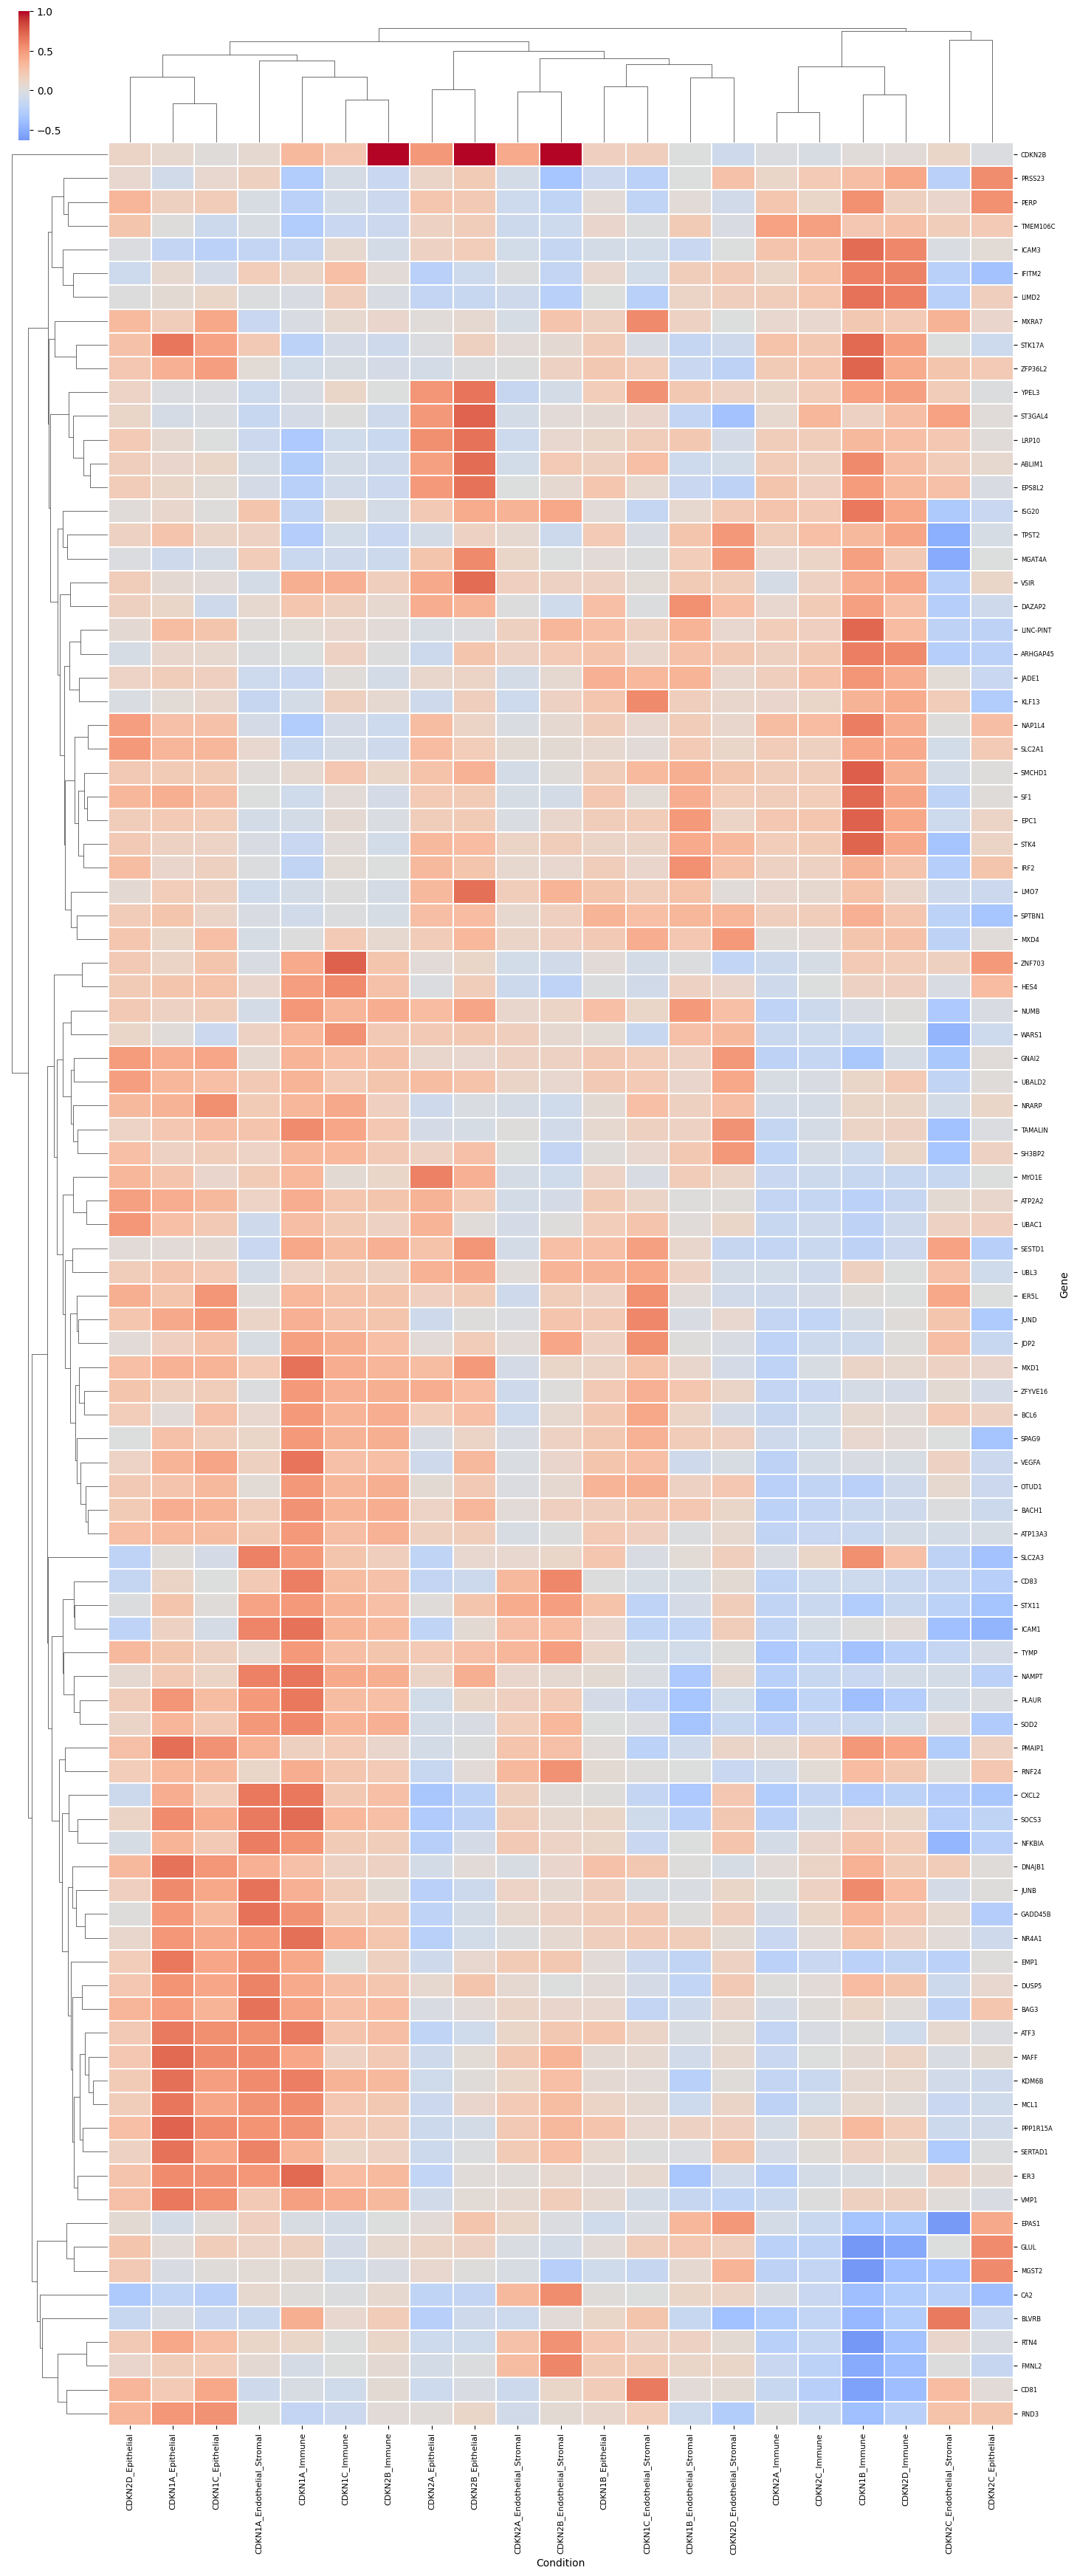

In [23]:
plot_clustermap(feat_multi);

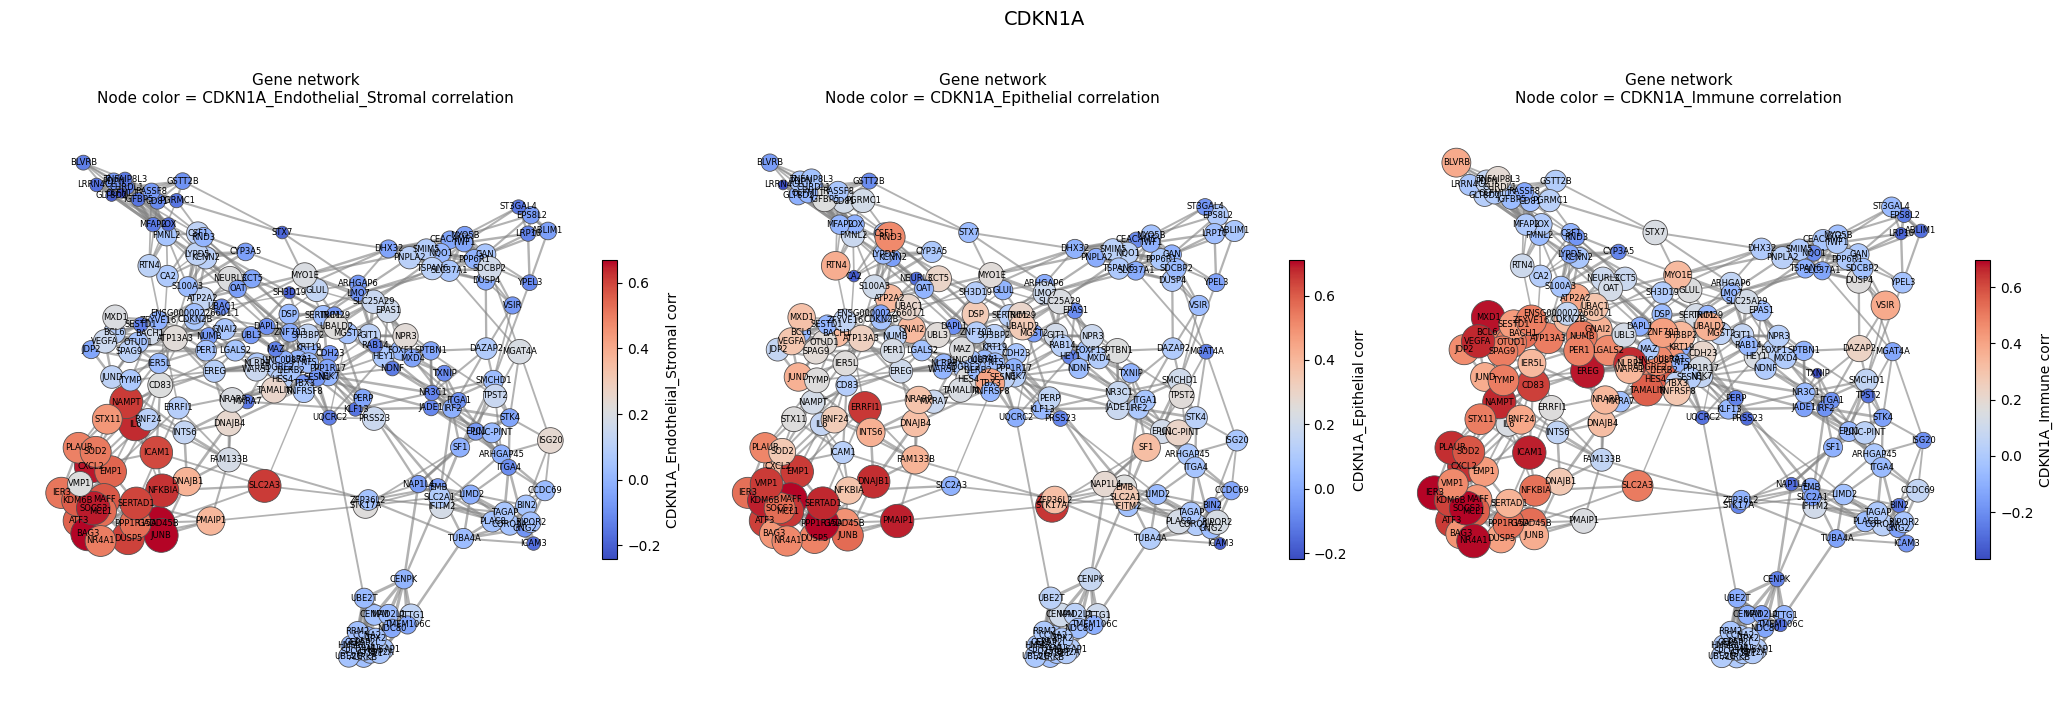

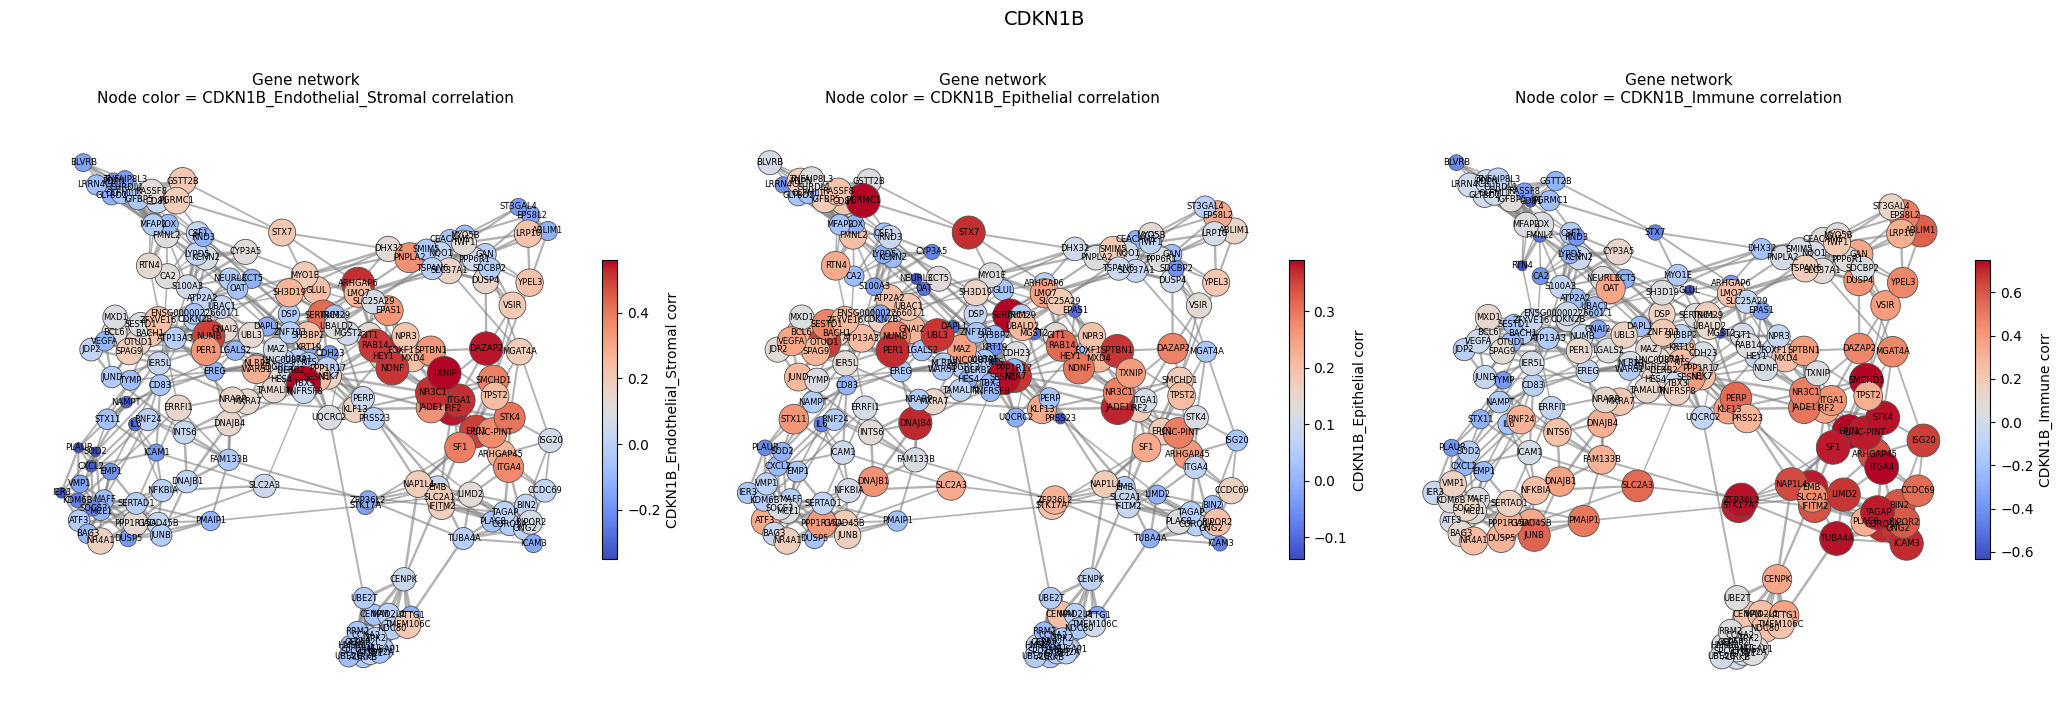

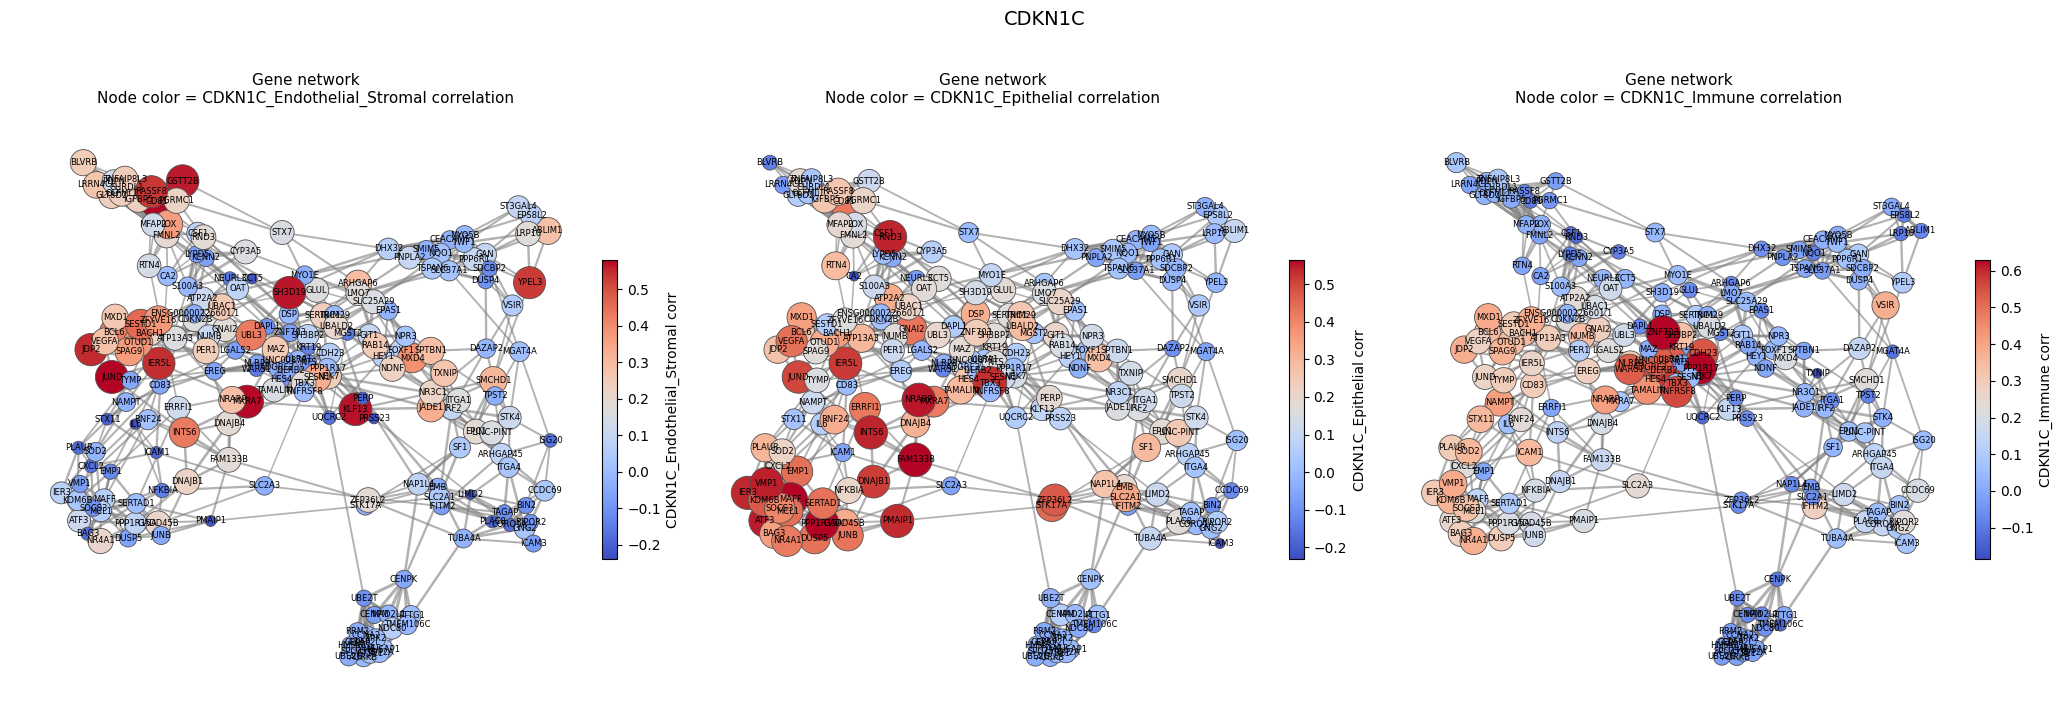

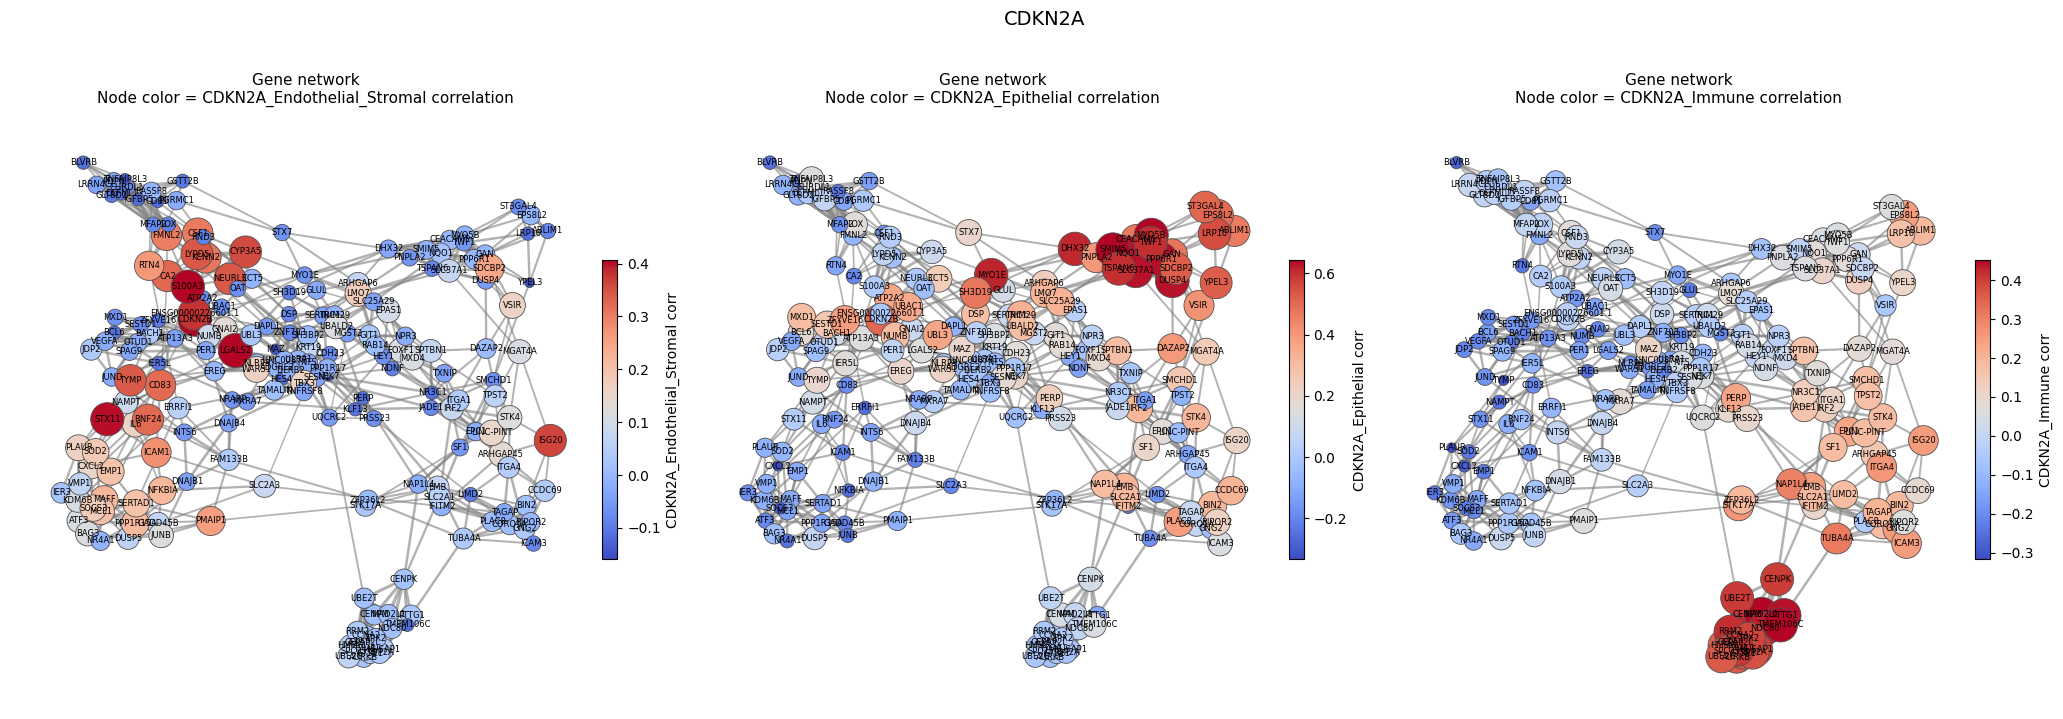

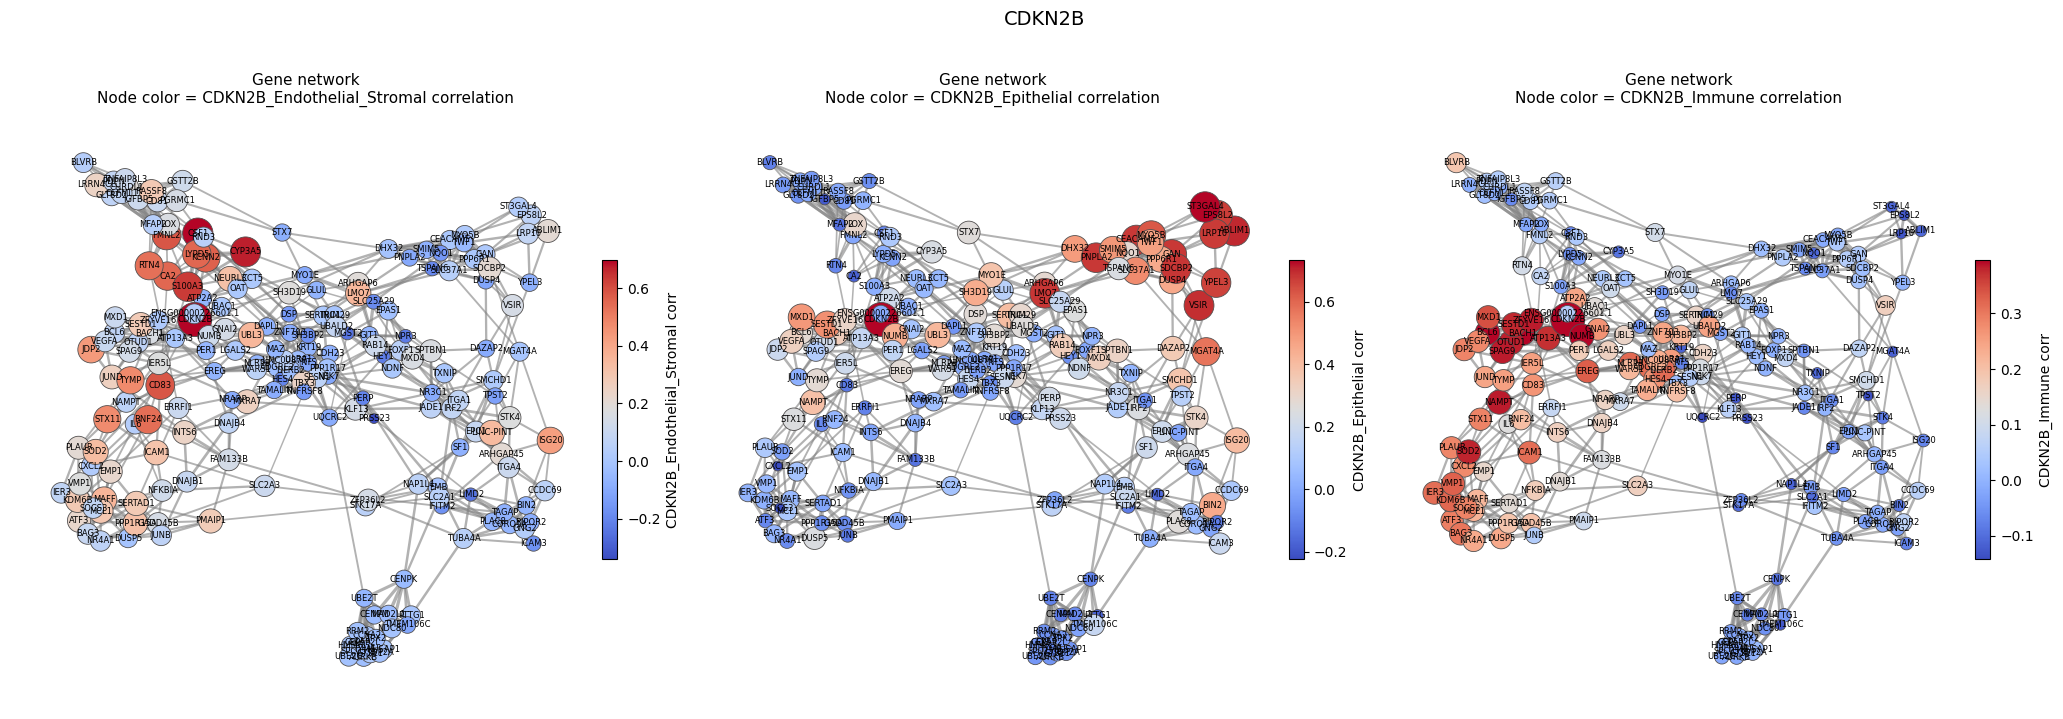

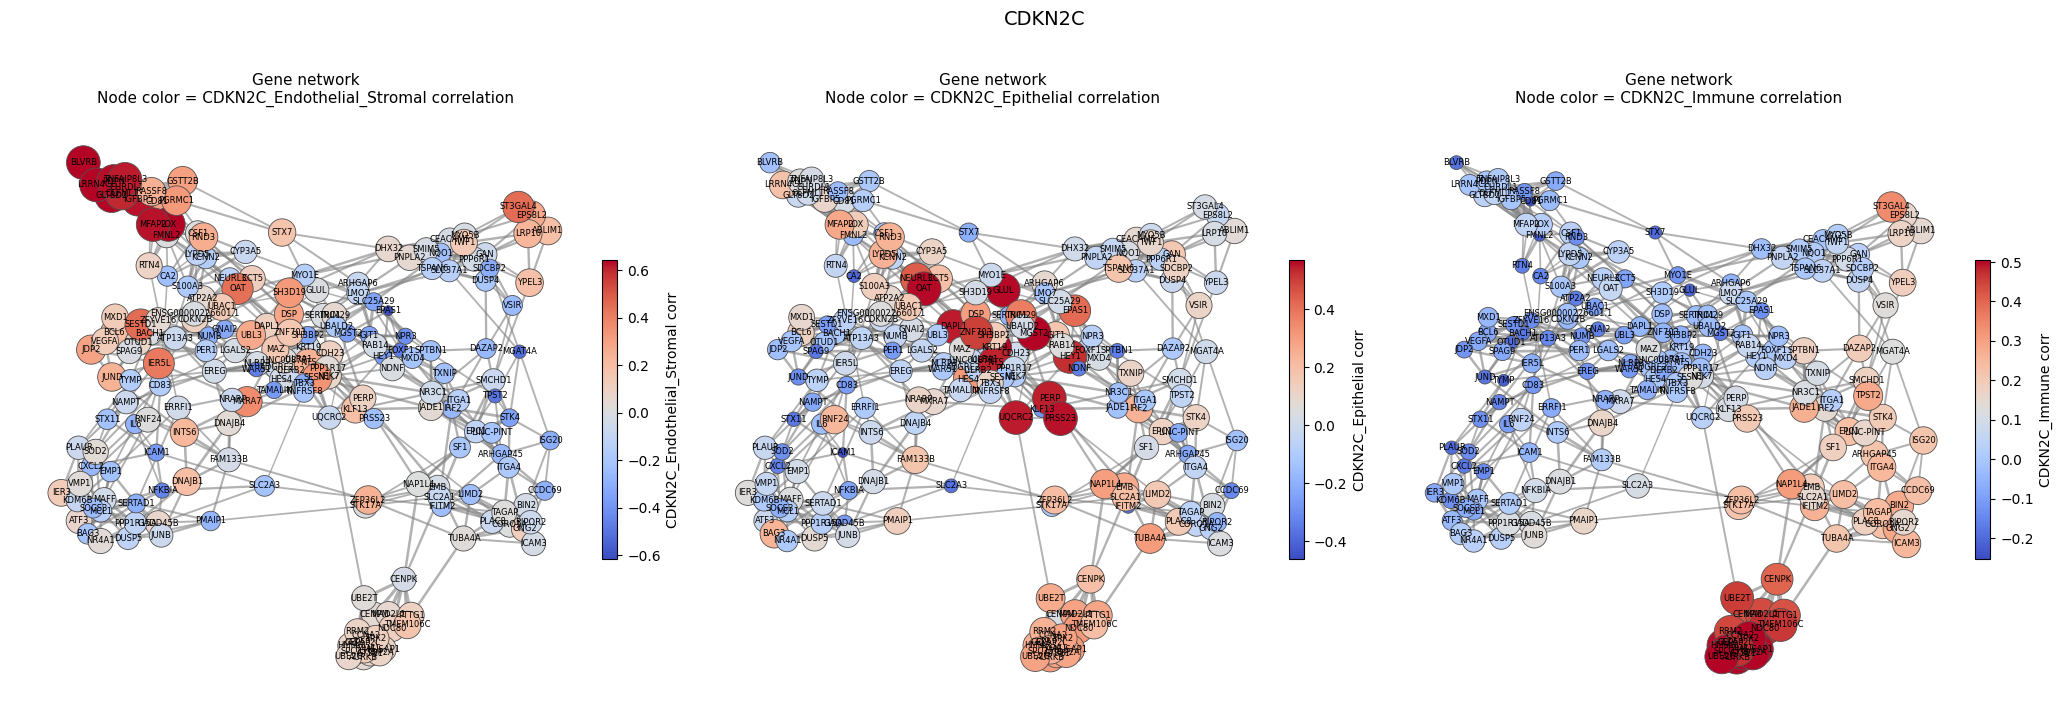

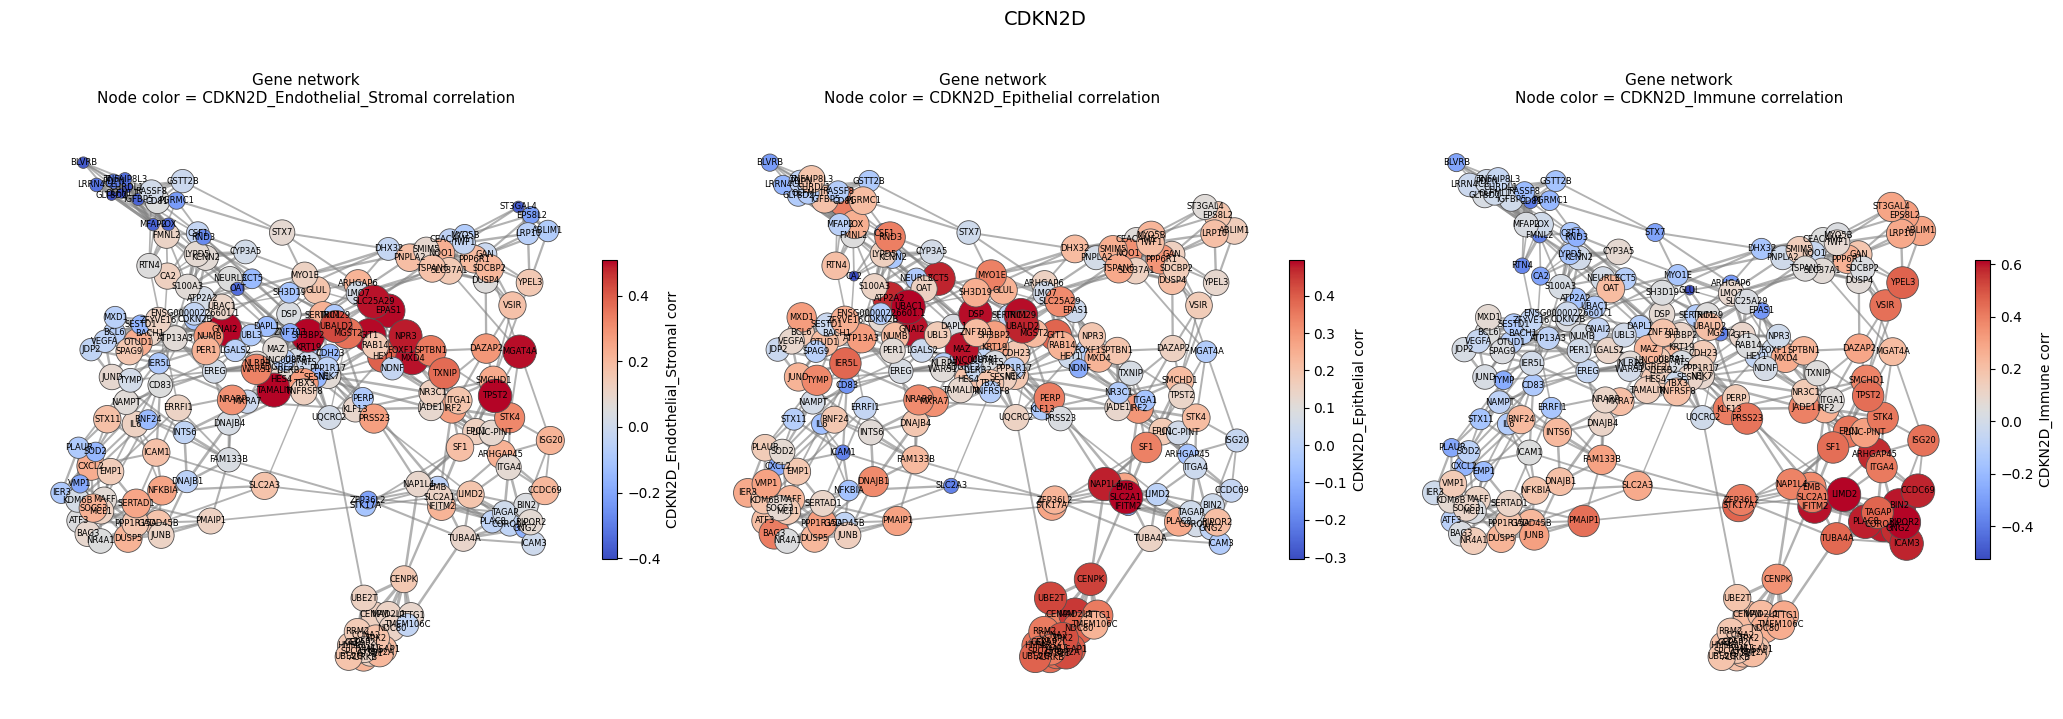

In [24]:
for goi in ['CDKN1A', 'CDKN1B', 'CDKN1C', 'CDKN2A', 'CDKN2B', 'CDKN2C', 'CDKN2D']:
    cols = [c for c in feat_multi.columns if c.startswith(f'{goi}_')]
    fig, axes = plt.subplots(1, len(cols), figsize=(7*len(cols), 7), squeeze=False)
    for ax, cond in zip(axes.ravel(), cols):
        plot_network(G_multi, feature_matrix=feat_multi, condition=cond, pos=pos_multi, ax=ax)
    fig.suptitle(goi, fontsize=14, y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)